# Generative Adversarial Network (GAN) Implementation in PyTorch

This notebook implements a **Generative Adversarial Network (GAN)** from scratch using PyTorch to generate handwritten digit images similar to the MNIST dataset.

### Learning Objectives:
- Understand the architecture of GANs (Generator and Discriminator)
- Implement convolutional and transpose convolutional layers
- Train adversarial networks with competing objectives
- Generate synthetic images from random noise

### What is a GAN?
A GAN consists of two neural networks competing against each other:
1. **Generator (G)**: Creates fake samples from random noise
2. **Discriminator (D)**: Distinguishes between real and fake samples

The Generator tries to fool the Discriminator, while the Discriminator tries to correctly identify real vs. fake samples. This adversarial training process leads to the Generator producing increasingly realistic samples.

In [1]:
import torch
import torch.nn as nn
import numpy as np
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython import display
from torch.nn import BCELoss

In [3]:
# Durante le epoche di addestramento voglio rendermi conto cosa è in grado
# di generare il Generatore

def plot(samples):
    fig = plt.figure(figsize=(4, 4))
    gs = gridspec.GridSpec(4, 4)
    gs.update(wspace=0.05, hspace=0.05)

    for i, sample in enumerate(samples):
        ax = plt.subplot(gs[i])
        plt.axis("off")
        plt.imshow(sample.reshape(28, 28), cmap="Greys_r")

    return fig

## Step 2: Define Constants and Setup

Here we define key hyperparameters:
- **z_size**: The dimension of the latent space (input noise vector for the Generator)
- **batch_size**: Number of samples processed in each training iteration
- **device**: Use GPU if available for faster training

In [4]:
z_size= 100
batch_size = 128

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")



## Step 3: Load MNIST Dataset

The MNIST dataset contains 28×28 grayscale images of handwritten digits (0-9). We load both training and test sets and create DataLoaders for efficient batching.

In [6]:
mnist_train = MNIST("./data", download=True, transform=ToTensor())
mnist_test = MNIST("./data", download=True, train=False, transform=ToTensor())

mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)
mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=True)

## Step 4: Generator Network Architecture

The **Generator** transforms random noise into synthetic images:

### Architecture:
1. **Input**: Random noise vector of size 64 (reshaped to 64×1×1)
2. **Layer 1**: ConvTranspose2d (64→32 channels, 7×7 kernel) → BatchNorm → ReLU
   - Output: 32×7×7
3. **Layer 2**: ConvTranspose2d (32→16 channels, 3×3 kernel, stride=2) → BatchNorm → ReLU
   - Output: 16×14×14
4. **Layer 3**: ConvTranspose2d (16→1 channel, 3×3 kernel, stride=2)
   - Output: 1×28×28 (final image)

### Key Concepts:
- **ConvTranspose2d** (Deconvolution): Upsamples the input to create larger images
- **BatchNorm**: Normalizes activations for stable training
- **ReLU**: Activation function for non-linearity

In [13]:
class Generator(nn.Module):
    def __init__(self, z_size=100):
      super().__init__()
      self.z_size = z_size

      self.gen_layer1 = nn.Sequential(
          # Sostituisci 64 con self.z_size
          nn.ConvTranspose2d(
              self.z_size, 32, kernel_size=7, stride=1, padding=0
          ),
          nn.BatchNorm2d(32),
          nn.ReLU(),
      )
      self.gen_layer2 = nn.Sequential(
          nn.ConvTranspose2d(
              32, 16, kernel_size=3, stride=2, padding=1, output_padding=1
          ),
          nn.BatchNorm2d(16),
          nn.ReLU(),
      )
      self.gen_layer3 = nn.Sequential(
          nn.ConvTranspose2d(
              16, 1, kernel_size=3, stride=2, padding=1, output_padding=1
          ),
          nn.Sigmoid(),
      )

        # Discriminator

    def forward(self, x):
        x = x.view(-1, self.z_size, 1, 1)
        x = self.gen_layer1(x)
        x = self.gen_layer2(x)
        x = self.gen_layer3(x)
        return x

    def sample(self, n):
        z = torch.randn(n, self.z_size)
        return z

    def generate(self, n=1):
        z = self.sample(n).to(device)
        return self.forward(z)

## Step 5: Discriminator Network Architecture

The **Discriminator** classifies images as real or fake:

### Architecture:
1. **Input**: Image of size 1×28×28
2. **Layer 1**: Conv2d (1→16 channels, 3×3 kernel, stride=2) → BatchNorm → LeakyReLU
   - Output: 16×14×14
3. **Layer 2**: Conv2d (16→32 channels, 3×3 kernel, stride=2) → BatchNorm → LeakyReLU
   - Output: 32×7×7
4. **Layer 3**: Conv2d (32→64 channels, 7×7 kernel) → BatchNorm → LeakyReLU
   - Output: 64×1×1
5. **Layer 4**: Conv2d (64→1 channel, 1×1 kernel) → Sigmoid
   - Output: Probability (0=fake, 1=real)

### Key Concepts:
- **Conv2d**: Downsamples the input to extract features
- **LeakyReLU**: Allows small negative gradients (better for discriminator)
- **Sigmoid**: Outputs probability between 0 and 1

In [9]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()

        self.dis_layer1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(),
        )

        self.dis_layer2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(),
        )

        self.dis_layer3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=7, stride=1, padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(),
        )

        self.dis_layer4 = nn.Sequential(
            nn.Conv2d(64, 1, kernel_size=1, stride=1, padding=0),
            nn.Sigmoid(),
        )

    def forward(self, x):
        x = self.dis_layer1(x)
        x = self.dis_layer2(x)
        x = self.dis_layer3(x)
        x = self.dis_layer4(x)
        return x


## Step 6: Training Setup and Loss Functions

### Initialization:
- Create instances of Generator and Discriminator
- Move models to GPU if available
- Setup Adam optimizers with learning rate 0.0002 and beta values (0.5, 0.999)

### Loss Functions:
1. **Discriminator Loss**: Binary Cross-Entropy (BCE)
   - Wants to output 1 for real images, 0 for fake images
2. **Generator Loss**: Negative log-likelihood
   - Wants the Discriminator to output 1 for its fake images

### Training Functions:
- `train_discriminator()`: Updates D to better distinguish real from fake
- `train_generator()`: Updates G to better fool the Discriminator
- `train()`: Main training loop that alternates between updating D and G

In [10]:
def train_discriminator(dis, real_data, fake_data):
    dis.train()
    dis_opt.zero_grad()

    # Train on real data
    real_pred = dis(real_data)
    real_loss = d_loss(real_pred, torch.ones_like(real_pred))
    real_loss.backward()

    # Train on fake data
    fake_pred = dis(fake_data)
    fake_loss = d_loss(fake_pred, torch.zeros_like(fake_pred))
    fake_loss.backward()

    dis_opt.step()

    return real_loss + fake_loss


def train_generator(gen, dis, fake_data):

    gen.train()
    gen_opt.zero_grad()

    fake_pred = dis(fake_data)
    gen_loss = g_loss(fake_pred, torch.ones_like(fake_pred))
    gen_loss.backward()

    gen_opt.step()

    return gen_loss


def train(gen, dis, train_loader, epochs=10, samples=None):
    for epoch in range(epochs):
        for i, (real_data, _) in enumerate(train_loader):
            real_data = real_data.to(device)

            # Generate fake data once
            fake_data = gen.generate(real_data.shape[0])

            # Train discriminator with detached fake data (no gradients to generator)
            dis_loss = train_discriminator(dis, real_data, fake_data.detach())

            # Train generator with same fake data (with gradients)
            gen_loss = train_generator(gen, dis, fake_data)

            if i % 100 == 0:
                print(
                    f"Epoch: {epoch}, Step: {i}, Discriminator Loss: {dis_loss}, Generator Loss: {gen_loss}"
                )

                gen.eval()
                generated = gen.forward(samples).detach().cpu().numpy()

                display.clear_output(wait=True)
                fig = plot(generated)
                fig.suptitle(
                    f"Epoch: {epoch}, Step: {i}\n DLoss: {dis_loss:2.4f}, GLoss: {gen_loss:2.4f}"
                )
                display.display(fig)
                plt.savefig(f"images/wgan_conv_e{epoch}_s{i}.png")

                plt.close(fig)

In [14]:

gen = Generator().to(device)
dis = Discriminator().to(device)

gen_opt = torch.optim.Adam(gen.parameters(), lr=0.0002, betas=(0.5, 0.999))
dis_opt = torch.optim.Adam(dis.parameters(), lr=0.0002, betas=(0.5, 0.999))

d_loss = nn.BCELoss()
def g_loss(y_pred, y_true):
    return BCELoss()(y_pred, y_true)


## Step 7: Train the GAN

Now we train the GAN for 10 epochs. During training:
1. The Discriminator learns to identify real MNIST images vs. generated fake images
2. The Generator learns to create more realistic fake images that fool the Discriminator

The training alternates between:
- **Discriminator update**: Train on both real and fake images
- **Generator update**: Generate new fake images and try to fool the Discriminator

**Note**: Training may take several minutes. Watch how the losses change over time!

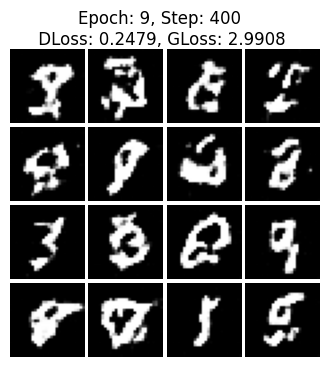

In [16]:
gen.eval()
samples = gen.sample(16).to(device)
train(gen, dis, mnist_train_loader, epochs=10, samples=samples)

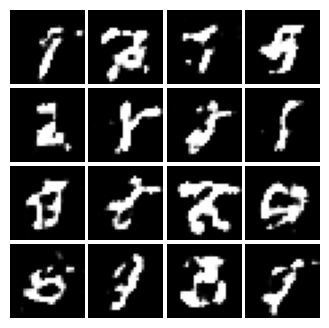

In [18]:
gen.eval()
samples = gen.generate(16).detach().cpu().numpy()

# 1. Chiama plot solo con samples
fig = plot(samples)

# 2. Salva la figura su disco
fig.savefig("generated_images.png")

# 3. Mostra la figura a schermo
plt.show()